<div style="
    font-family: 'Poppins', sans-serif;
    background: linear-gradient(135deg, #001f3f, #003366);
    color: white;
    width: 700px;
    padding: 30px;
    border-radius: 15px;
    margin: 40px auto;
    box-shadow: 0 8px 16px rgba(0, 0, 0, 0.4);
    text-align: center;
    border: 2px solid #00509e;
">
    <h1 style="font-size: 48px; margin-bottom: 20px; text-transform: letter-spacing: 2px; color: #87CEEB;"><strong>Jose Carlos Fernandez</strong><h1>
    <p style="font-size: 22px; margin: 10px 0;"><strong>Matrícula:</strong> 2024-0371</p>
    <p style="font-size: 22px; margin: 10px 0;"><strong>Fecha:</strong> 26 de Julio de 2025</p>
    <p style="font-size: 22px; margin: 10px 0;"><strong>Maestro:</strong> Jose Manuel Aquino</p>
    <p style="font-size: 22px; margin: 10px 0;"><strong>Instituto Tecnologico de Las Americas ITLA</p>
</div>


<div style="
    font-family: 'Poppins', sans-serif;
    background: linear-gradient(135deg, #001f3f, #003366);
    color: white;
    width: 50%;
    padding: 30px;
    border-radius: 15px;
    margin: 40px auto;
    box-shadow: 0 8px 16px rgba(0, 0, 0, 0.4);
    text-align: center;
    border: 2px solid #00509e;
">
    <h2 style="font-size: 28px; margin-bottom: 15px; color: #87CEEB;"><strong>Trabajo Final</strong></h2>
    <p style="font-size: 18px; margin: 10px 0; font-weight: 500; color: #f0f8ff;">
        Programacion 3.
    </p>
</div>

<hr style="
    border: none;
    border-top: 15px solid #003366;
    border-radius: 8px;
    width: 80%;
    margin: 80px auto;
">

# **🎟️ Introduccion**

**Muy buenas tardes profe y a todo aquel que este leyendo esto, en este trabajo voy a estar haciendo un analisis sobre los `accidentes de transito` en Republica Dominicana... estos datos han sido extraidos desde `Datos Abiertos Gob RD`, y fueron proporcionados por la DIGESSET.**

**Para la elaboracion de este trabajo, voy a seguir la siguiente estructura:**

- 1. Exploración inicial `(Python)`
- 2. Limpieza y transformación de datos `(Python)`
- 3. Análisis descriptivo y estadístico `(R)`
- 4. Visualización de datos `(R)`

> **OJO👁️: todo este proceso lo voy a estar haciendo en un Jupyter Notebook, sin embargo voy a usar los 2 lenguajes requeridos para la realizacion de el trabajo: `Python` y `R`**

> **LINK del dataset 🔗: https://datos.gob.do/dataset/estadistica-de-fallecimientos-por-accidentes-de-transito**

In [73]:
# Importacion de librerias

# ===== Para manejo y limpieza de datos (Python) =====

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
# Como no voy a graficar con Python, no es necesario importar matplotlib

# Para usar R en Jupyter
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [74]:
%%R
# Librerias de R
library(dplyr)
library(ggplot2)
library(readr)
library(tidyr)
library(lubridate)
library(corrplot)
library(gridExtra)
library(plotly)
library(DT)
library(psych)
library(VIM)
library(mice)
library(stringr)
library(scales)
library(RColorBrewer)

<hr style="
    border: none;
    border-top: 15px solid #003366;
    border-radius: 8px;
    width: 80%;
    margin: 80px auto;
">

<div style="
    font-family: 'Poppins', sans-serif;
    background: linear-gradient(135deg, #014775ff, #003366);
    color: white;
    width: 50%;
    padding: 30px;
    border-radius: 15px;
    margin: 40px auto;
    box-shadow: 0 8px 16px rgba(0, 0, 0, 0.4);
    text-align: center;
    border: 2px solid #00509e;
">
    <h2 style="font-size: 28px; margin-bottom: 15px; color: #87CEEB;"><strong>Python 🐍</strong></h2>
    <p style="font-size: 18px; margin: 10px 0; font-weight: 500; color: #f0f8ff;">
    </p>
</div>

# **1. Exploracion Inicial**

 ## **Importacion de datos**

In [75]:
ruta = r'C:\Users\josecarlos\Downloads\Data Accidentes 2026-2025.csv'
df = pd.read_csv(ruta, encoding='latin1')

# Separamos la columna en tres columnas por el punto y coma
df = df['Tipo de Accidente;FALLECIDOS;AÑO'].str.split(';', expand=True) # Separar por punto y coma
df.columns = ['Tipo de Accidente', 'FALLECIDOS', 'AÑO'] # Asignar nombres a las columnas

<hr style="
    border: none;
    border-top: 15px solid #014775ff;
    border-radius: 8px;
    width: 80%;
    margin: 80px auto;
">

 ## **Convertimos FALLECIDOS y AÑO a numerico**

In [76]:
df['FALLECIDOS'] = pd.to_numeric(df['FALLECIDOS'], errors='coerce') # errors='coerce' convierte los errores a NaN
df['AÑO'] = pd.to_numeric(df['AÑO'], errors='coerce')

<hr style="
    border: none;
    border-top: 15px solid #014775ff;
    border-radius: 8px;
    width: 80%;
    margin: 80px auto;
">

 ## **Informacion del dataframe**

In [77]:
print("=== 🔵INFORMACION BASICA DEL DATASET🔵 ===")
print(f"Dimensiones: {df.shape}")
print(f"Columnas: {list(df.columns)}")
print("\n=== PRIMERAS 10 FILAS ===")
df.head(10)

=== 🔵INFORMACION BASICA DEL DATASET🔵 ===
Dimensiones: (92, 3)
Columnas: ['Tipo de Accidente', 'FALLECIDOS', 'AÑO']

=== PRIMERAS 10 FILAS ===


,Tipo de Accidente,FALLECIDOS,AÑO
0,Colisiones,1179,2016
1,Deslizamientos,391,2016
2,Atropellos,324,2016
3,Estrellamientos,67,2016
4,Caídas desde Vehículos en Movimiento,13,2016
5,Volcaduras de Vehículo,7,2016
6,Colisiones con Animales,12,2016
7,Aplastamiento,0,2016
8,Sin Especificación,0,2016
9,Colisiones,913,2017


<hr style="
    border: none;
    border-top: 15px solid #014775ff;
    border-radius: 8px;
    width: 80%;
    margin: 80px auto;
">

## **Estadisticas y analisis preliminar**

In [78]:
print("\n=== 🔵INFORMACION DE TIPOS DE DATOS🔵 ===")
df.info()


=== 🔵INFORMACION DE TIPOS DE DATOS🔵 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Tipo de Accidente  92 non-null     object
 1   FALLECIDOS         92 non-null     int64 
 2   AÑO                92 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 2.3+ KB


<hr style="
    border: none;
    border-top: 15px solid #014775ff;
    border-radius: 8px;
    width: 80%;
    margin: 80px auto;
">

## **Estadisticas descriptivas**

In [79]:
print("\n=== ⬇️ESTADISTICAS DESCRIPTIVAS⬇️ ===")
df.describe()


=== ⬇️ESTADISTICAS DESCRIPTIVAS⬇️ ===


,FALLECIDOS,AÑO
count,92.000000,92.000000
mean,190.000000,2020.597826
std,333.570923,2.901533
min,0.000000,2016.000000
25%,2.000000,2018.000000
50%,11.000000,2021.000000
75%,272.750000,2023.000000
max,1327.000000,2025.000000


<hr style="
    border: none;
    border-top: 15px solid #014775ff;
    border-radius: 8px;
    width: 80%;
    margin: 80px auto;
">

## **Valores unicos por columna**

In [80]:
print("\n=== ⬇️VALORES UNICOS POR COLUMNA⬇️ ===")
for col in df.columns: # Por cada columna en el DataFrame
    print(f"{col}: {df[col].nunique()} valores unicos") # Imprime el nombre de la columna y el conteo de valores unicos


=== ⬇️VALORES UNICOS POR COLUMNA⬇️ ===
Tipo de Accidente: 32 valores unicos
FALLECIDOS: 54 valores unicos
AÑO: 10 valores unicos


<hr style="
    border: none;
    border-top: 15px solid #014775ff;
    border-radius: 8px;
    width: 80%;
    margin: 80px auto;
">

## **Analisis de columnas con valores nulos**

In [81]:
print("\n=== ⬇️VALORES NULOS⬇️ ===")
print(df.isnull().sum())


=== ⬇️VALORES NULOS⬇️ ===
Tipo de Accidente    0
FALLECIDOS           0
AÑO                  0
dtype: int64


<hr style="
    border: none;
    border-top: 15px solid #014775ff;
    border-radius: 8px;
    width: 80%;
    margin: 80px auto;
">

# **2. Limpieza y transformacion de datos (Python)**

## **Vamos a crear una copia del dataset, para poder trabajar y tener un buen control**

In [82]:
df_clean = df.copy()

<hr style="
    border: none;
    border-top: 15px solid #014775ff;
    border-radius: 8px;
    width: 80%;
    margin: 80px auto;
">

## **Limpieza de nombres de columnas**

In [83]:
df_clean.columns = ['tipo_accidente', 'fallecidos', 'anio'] # Sustitucion de Tipo de Accidente, FALLECIDOS y AÑO por minusculas y sin espacios
df_clean.head()

,tipo_accidente,fallecidos,anio
0,Colisiones,1179,2016
1,Deslizamientos,391,2016
2,Atropellos,324,2016
3,Estrellamientos,67,2016
4,Caídas desde Vehículos en Movimiento,13,2016


<hr style="
    border: none;
    border-top: 15px solid #014775ff;
    border-radius: 8px;
    width: 80%;
    margin: 80px auto;
">

## **Limpieza de caracteres especiales en `tipo_accidente`**

In [84]:
df_clean['tipo_accidente'] = df_clean['tipo_accidente'].str.replace('ñ', 'n')
df_clean['tipo_accidente'] = df_clean['tipo_accidente'].str.replace('í', 'i')
df_clean['tipo_accidente'] = df_clean['tipo_accidente'].str.replace('ó', 'o')
df_clean['tipo_accidente'] = df_clean['tipo_accidente'].str.replace('é', 'e')
df_clean['tipo_accidente'] = df_clean['tipo_accidente'].str.replace('á', 'a')
df_clean['tipo_accidente'] = df_clean['tipo_accidente'].str.replace('ú', 'u')

<hr style="
    border: none;
    border-top: 15px solid #014775ff;
    border-radius: 8px;
    width: 80%;
    margin: 80px auto;
">

## **Normalizacion de nombres de tipo de accidente**

In [85]:
df_clean['tipo_accidente'] = df_clean['tipo_accidente'].str.strip() # Esto elimina espacios al inicio y al final de la cadena para cada fila
df_clean['tipo_accidente'] = df_clean['tipo_accidente'].str.title() # La primera letra de cada palabra mayuscula y el resto a minuscula (igual que un titulo)

<hr style="
    border: none;
    border-top: 15px solid #014775ff;
    border-radius: 8px;
    width: 80%;
    margin: 80px auto;
">

## **Verificacion y correccion de inconsistencias en nombres**

In [86]:
print("=== ⬇️TIPOS DE ACCIDENTE ANTES DE NORMALIZACION⬇️ ===")
print(df_clean['tipo_accidente'].value_counts())

=== ⬇️TIPOS DE ACCIDENTE ANTES DE NORMALIZACION⬇️ ===
Aplastamiento                           7
Sin Especificacion                      7
Colisiones                              5
Caida                                   5
Deslizamientos                          5
Deslizamiento                           5
Colision                                5
Estrellamiento                          5
Estrellamientos                         5
Colisiones Con Animales                 4
Caidas Desde Vehiculos En Movimiento    4
Atropellos                              4
Volcadura                               4
Atropello                               4
Volcaduras De Vehiculo                  3
Volcaduras                              2
Aplastamientos                          2
Colision Y Atropello                    2
Caida Y Atropello                       1
Estrellamiento Y Colision               1
Deslizamiento Y Estrellamiento          1
Deslizamiento Y Atropello               1
Colision Y Aplastamien

> Al revisar los tipos de accidentes, se identifican multiples variaciones de un mismo evento, como **"Colision"**, **"Colisiones"**, **"Deslizamiento"** y **"Deslizamientos"**, asi como errores ortograficos y combinaciones innecesarias. Esto fragmenta los datos y dificulta el analisis. Por ello, se realizara una normalizacion para unificar estos registros bajo categorias estandar, lo que permitira obtener resultados mas precisos y consistentes.


<hr style="
    border: none;
    border-top: 15px solid #014775ff;
    border-radius: 8px;
    width: 80%;
    margin: 80px auto;
">

## **Normalizacion de variaciones del mismo tipo**

In [87]:
# Diccionario de normalizacion de tipo de accidente
normalizacion_accidentes = {
    'Colision': 'Colisiones',
    'Colision Y Atropello': 'Colisiones',
    'Colision Y Aplastamiento': 'Colisiones',
    'Estrellamiento': 'Estrellamientos',
    'Estrellamiento Y Colision': 'Estrellamientos',
    'Deslizamiento': 'Deslizamientos',
    'Deslizamiento Y Estrellamiento': 'Deslizamientos',
    'Deslizamiento Y Atropello': 'Deslizamientos',
    'Atropello': 'Atropellos',
    'Atropellamiento': 'Atropellos',
    'Atropellamientos': 'Atropellos',
    'Caidas': 'Caidas Desde Vehiculos',
    'Caida': 'Caidas Desde Vehiculos',
    'Caida Y Atropello': 'Caidas Desde Vehiculos',
    'Caida Y Atroppellamiento': 'Caidas Desde Vehiculos',
    'Caidas Desde Vehiculos': 'Caidas Desde Vehiculos',
    'Caidas Desde Vehiculos En Movimiento': 'Caidas Desde Vehiculos',
    'Cada': 'Caidas Desde Vehiculos',
    'Caida De Arbol': 'Caidas Desde Vehiculos',
    'Aplastamiento': 'Aplastamientos',
    'Aplastamientos': 'Aplastamientos',
    'Aplastamiento De Persona': 'Aplastamientos',
    'Aplastamiento De Personas': 'Aplastamientos',
    'Volcadura': 'Volcaduras',
    'Volcaduras De Vehiculo': 'Volcaduras',
    'Volcaduras': 'Volcaduras',
}

# Aplicamos el reemplazo
df_clean['tipo_accidente'] = df_clean['tipo_accidente'].replace(normalizacion_accidentes)

# Estas clasificaciones las he definido desde mi criterio, basandome en las variaciones que he encontrado en el dataset


<hr style="
    border: none;
    border-top: 15px solid #014775ff;
    border-radius: 8px;
    width: 80%;
    margin: 80px auto;
">

## **Verificar datos limpios para ver si el proceso funciono**

In [88]:
print("\n=== ⬇️TIPOS DE ACCIDENTE DESPUES DE NORMALIZACION⬇️ ===")
print(df_clean['tipo_accidente'].value_counts())


=== ⬇️TIPOS DE ACCIDENTE DESPUES DE NORMALIZACION⬇️ ===
Colisiones                 13
Caidas Desde Vehiculos     13
Deslizamientos             12
Estrellamientos            11
Atropellos                 10
Volcaduras                  9
Aplastamientos              9
Sin Especificacion          7
Colisiones Con Animales     4
Quemaduras                  1
Arrastramiento              1
Estrangulamiento            1
Golpe Contuso               1
Name: tipo_accidente, dtype: int64


> Luego de la normalizacion, se logro unificar las variaciones de los tipos de accidentes, reduciendo la fragmentacion de categorias y mejorando la consistencia de los datos para un analisis mas preciso. 👍

<hr style="
    border: none;
    border-top: 15px solid #014775ff;
    border-radius: 8px;
    width: 80%;
    margin: 80px auto;
">

## **Verificacion de los datos ya procesados y limpiados**

In [89]:
print("\n=== 🔵VERIFICACION DE DATOS LIMPIOS🔵 ===")
print(f"Total de registros: {len(df_clean)}")
print(f"Valores nulos: {df_clean.isnull().sum().sum()}")
print(f"Rango de anios: {df_clean['anio'].min()} - {df_clean['anio'].max()}")


=== 🔵VERIFICACION DE DATOS LIMPIOS🔵 ===
Total de registros: 92
Valores nulos: 0
Rango de anios: 2016 - 2025


<hr style="
    border: none;
    border-top: 15px solid #014775ff;
    border-radius: 8px;
    width: 80%;
    margin: 80px auto;
">

## **Creacion de variable adicional `periodo`**

In [90]:
df_clean['periodo'] = pd.cut(df_clean['anio'], # cut funciona para dividir los datos en intervalos y asi poder generar periodos
                           bins=[2015, 2018, 2021, 2025], 
                           labels=['2016-2018', '2019-2021', '2022-2025'])

# Me daria error si trato de pasar una columna categorica a R, asi que la convierto a string
df_clean['periodo'] = df_clean['periodo'].astype(str)

<hr style="
    border: none;
    border-top: 15px solid #014775ff;
    border-radius: 8px;
    width: 80%;
    margin: 80px auto;
">

## **Incorporacion del dataframe con datos de `dia de la semana`**

In [91]:
ruta = r'C:\Users\josecarlos\Downloads\Accidentes por dia de semana.csv'
df_dia_semana = pd.read_csv(ruta, encoding='latin1') # latin1 es un encoding que permite leer caracteres especiales en español

# Quitamos los caracteres especiales y espacios en blanco al inicio y al final de la cadena
df_dia_semana['DIA DE SEMANA;FALLECIDOS;AÑO'] = df_dia_semana['DIA DE SEMANA;FALLECIDOS;AÑO'].str.strip() # Esto elimina espacios al inicio y al final de la cadena para cada fila
df_dia_semana['DIA DE SEMANA;FALLECIDOS;AÑO'] = df_dia_semana['DIA DE SEMANA;FALLECIDOS;AÑO'].str.replace('ñ', 'n')
df_dia_semana['DIA DE SEMANA;FALLECIDOS;AÑO'] = df_dia_semana['DIA DE SEMANA;FALLECIDOS;AÑO'].str.replace('í', 'i')
df_dia_semana['DIA DE SEMANA;FALLECIDOS;AÑO'] = df_dia_semana['DIA DE SEMANA;FALLECIDOS;AÑO'].str.replace('ó', 'o')
df_dia_semana['DIA DE SEMANA;FALLECIDOS;AÑO'] = df_dia_semana['DIA DE SEMANA;FALLECIDOS;AÑO'].str.replace('é', 'e')
df_dia_semana['DIA DE SEMANA;FALLECIDOS;AÑO'] = df_dia_semana['DIA DE SEMANA;FALLECIDOS;AÑO'].str.replace('á', 'a')
df_dia_semana['DIA DE SEMANA;FALLECIDOS;AÑO'] = df_dia_semana['DIA DE SEMANA;FALLECIDOS;AÑO'].str.replace('ú', 'u')


# Separamos la columna en tres columnas por el punto y coma
df_dia_semana = df_dia_semana['DIA DE SEMANA;FALLECIDOS;AÑO'].str.split(';', expand=True) # Separar por punto y coma
df_dia_semana.columns = ['dia_semana', 'fallecidos', 'anio'] # Asignar nombres a las columnas
df_dia_semana['fallecidos'] = pd.to_numeric(df_dia_semana['fallecidos'], errors='coerce') # errors='coerce' convierte los errores a NaN
df_dia_semana['anio'] = pd.to_numeric(df_dia_semana['anio'], errors='coerce')

# Hay dias que tienen espacios al inicio y al final de la cadena, los quitamos para evitar problemas al graficar
df_dia_semana['dia_semana'] = df_dia_semana['dia_semana'].str.strip()

df_dia_semana

,dia_semana,fallecidos,anio
0,Lunes,334,2016
1,Martes,205,2016
2,Miercoles,191,2016
3,Jueves,197,2016
4,Viernes,230,2016
...,...,...,...
65,Miercoles,122,2025
66,Jueves,87,2025
67,Viernes,118,2025
68,Sabado,107,2025


In [92]:
df_dia_semana['dia_semana'].unique()  # Verifica los dias de la semana unicos

array(['Lunes', 'Martes', 'Miercoles', 'Jueves', 'Viernes', 'Sabado',
       'Domingo'], dtype=object)

<hr style="
    border: none;
    border-top: 15px solid #014775ff;
    border-radius: 8px;
    width: 80%;
    margin: 80px auto;
">

## **Incorporacion del dataframe con datos de `provincias`**

In [93]:
ruta = r'C:\Users\josecarlos\Downloads\Accidentes en provincias.csv'
df_provincias = pd.read_csv(ruta, encoding='latin1') # otra vez latin1 para leer caracteres especiales en español


# Quitamos los caracteres especiales que no son necesarios
df_provincias['Provincia;FALLECIDOS;AÑO'] = df_provincias['Provincia;FALLECIDOS;AÑO'].str.replace('ñ', 'n')
df_provincias['Provincia;FALLECIDOS;AÑO'] = df_provincias['Provincia;FALLECIDOS;AÑO'].str.replace('í', 'i')
df_provincias['Provincia;FALLECIDOS;AÑO'] = df_provincias['Provincia;FALLECIDOS;AÑO'].str.replace('ó', 'o')
df_provincias['Provincia;FALLECIDOS;AÑO'] = df_provincias['Provincia;FALLECIDOS;AÑO'].str.replace('é', 'e')
df_provincias['Provincia;FALLECIDOS;AÑO'] = df_provincias['Provincia;FALLECIDOS;AÑO'].str.replace('á', 'a')
df_provincias['Provincia;FALLECIDOS;AÑO'] = df_provincias['Provincia;FALLECIDOS;AÑO'].str.replace('ú', 'u')

# Quitamos los espacios al inicio y al final de la cadena
df_provincias['Provincia;FALLECIDOS;AÑO'] = df_provincias['Provincia;FALLECIDOS;AÑO'].str.strip() # Esto elimina espacios al inicio y al final de la cadena para cada fila

# Separamos la columna en tres columnas por el punto y coma
df_provincias = df_provincias['Provincia;FALLECIDOS;AÑO'].str.split(';', expand=True) # Separar por punto y coma
df_provincias.columns = ['provincia', 'fallecidos', 'anio'] # Asignar nombres a las columnas
df_provincias['fallecidos'] = pd.to_numeric(df_provincias['fallecidos'], errors='coerce') # errors='coerce' convierte los errores a NaN
df_provincias['anio'] = pd.to_numeric(df_provincias['anio'], errors='coerce')

df_provincias

,provincia,fallecidos,anio
0,Azua,64,2016
1,Bahoruco,21,2016
2,Barahona,34,2016
3,Dajabon,21,2016
4,Distrito Nacional,65,2016
...,...,...,...
315,Sanchez Ramirez,11,2025
316,Santiago,51,2025
317,Santiago Rodriguez,8,2025
318,Santo Domingo,122,2025


<hr style="
    border: none;
    border-top: 15px solid #014775ff;
    border-radius: 8px;
    width: 80%;
    margin: 80px auto;
">

## **🔵Datos Finales Para Analisis🔵**

In [94]:
# ==========================================================

print("\n=== 🔵DATOS DE TIPO DE ACCIDENTE🔵 ===")
print(df_clean.head())
print(f"\nForma final: {df_clean.shape}")
print("Nombre del dataframe: ➡️df_clean")
print("==========================================================")

# =========================================================

print("\n=== 🔵DATOS DE DIA DE SEMANA🔵 ===")
print(df_dia_semana.head())
print(f"\nForma final: {df_dia_semana.shape}")
print("Nombre del dataframe: ➡️df_dia_semana")
print("==========================================================")


# =========================================================

print("\n=== 🔵DATOS DE PROVINCIAS🔵 ===")
print(df_provincias.head())
print(f"\nForma final: {df_provincias.shape}")
print("Nombre del dataframe: ➡️df_provincias")
print("==========================================================")


# ==========================================================

print("\n=== 🔴FIN DEL PROCESO DE LIMPIEZA Y PREPARACION DE DATOS🔴 ===")


=== 🔵DATOS DE TIPO DE ACCIDENTE🔵 ===
           tipo_accidente  fallecidos  anio    periodo
0              Colisiones        1179  2016  2016-2018
1          Deslizamientos         391  2016  2016-2018
2              Atropellos         324  2016  2016-2018
3         Estrellamientos          67  2016  2016-2018
4  Caidas Desde Vehiculos          13  2016  2016-2018

Forma final: (92, 4)
Nombre del dataframe: ➡️df_clean

=== 🔵DATOS DE DIA DE SEMANA🔵 ===
  dia_semana  fallecidos  anio
0      Lunes         334  2016
1     Martes         205  2016
2  Miercoles         191  2016
3     Jueves         197  2016
4    Viernes         230  2016

Forma final: (70, 3)
Nombre del dataframe: ➡️df_dia_semana

=== 🔵DATOS DE PROVINCIAS🔵 ===
           provincia  fallecidos  anio
0               Azua          64  2016
1           Bahoruco          21  2016
2           Barahona          34  2016
3            Dajabon          21  2016
4  Distrito Nacional          65  2016

Forma final: (320, 3)
Nombre de

<hr style="
    border: none;
    border-top: 15px solid #014775ff;
    border-radius: 8px;
    width: 80%;
    margin: 80px auto;
">

## 📊 **Resumen del procesamiento de datos**

<div style="
    font-family: 'Segoe UI', sans-serif;
    background: linear-gradient(135deg, #1385a1ff, #0a6296ff, #1735b8ff);
    color: white;
    padding: 28px 24px 18px 24px;
    border-radius: 18px;
    margin: 30px auto 30px auto;
    box-shadow: 0 8px 18px rgba(0,0,0,0.18);
    border-left: 8px solid #ffc107;
    max-width: 800px;
">

  <div style="display: flex; align-items: center; margin-bottom: 12px;">
    <span style="font-size: 2em; margin-right: 12px;">🧼</span>
    <span style="font-size: 1.5em; font-weight: bold;">PROCESAMIENTO COMPLETADO</span>
  </div>

  <ul style="font-size: 1.08em; line-height: 1.7; margin-bottom: 18px; padding-left: 1.2em;">
    <li><b>✅ EXTRACCION:</b> Tres datasets criticos cargados y validados</li>
    <li><b>🧹 LIMPIEZA:</b> Caracteres especiales normalizados y categorias unificadas</li>
    <li><b>🔄 TRANSFORMACION:</b> Variables derivadas creadas para analisis avanzado</li>
    <li><b>🎯 RESULTADO:</b> Datasets consistentes listos para analisis estadistico en R</li>
  </ul>

  <div style="background: rgba(255,255,255,0.18); padding: 12px 0; border-radius: 10px; margin-top: 10px;">
    <span style="font-weight: bold; font-size: 1.13em; color: #fff; letter-spacing: 1px;">
      🔥 DATOS OPTIMIZADOS Y PREPARADOS PARA GRAFICAR EN R 🔥
    </span>
  </div>
</div>

<hr style="
    border: none;
    border-top: 15px solid #003366;
    border-radius: 8px;
    width: 80%;
    margin: 80px auto;
">

<div style="
    font-family: 'Poppins', sans-serif;
    background: linear-gradient(135deg, #001f3f, #003366);
    color: white;
    width: 50%;
    padding: 30px;
    border-radius: 15px;
    margin: 40px auto;
    box-shadow: 0 8px 16px rgba(0, 0, 0, 0.4);
    text-align: center;
    border: 2px solid #00509e;
">
    <h2 style="font-size: 28px; margin-bottom: 15px; color: #87CEEB;"><strong>R 🌄</strong></h2>
    <p style="font-size: 18px; margin: 10px 0; font-weight: 500; color: #f0f8ff;">
    </p>
</div>

# **Analisis Estadistico y Descriptivo**

<hr style="
    border: none;
    border-top: 15px solid #014775ff;
    border-radius: 8px;
    width: 80%;
    margin: 80px auto;
">

## **Primero traemos los datos que hemos logrado obtener en Python**

In [95]:
from rpy2.robjects import pandas2ri, globalenv

with pandas2ri.converter.context(): # Esta funcion permite convertir DataFrames de pandas a DataFrames de R
	globalenv['df_clean'] = pandas2ri.py2rpy(df_clean)
	globalenv['df_dia_semana'] = pandas2ri.py2rpy(df_dia_semana)
	globalenv['df_provincias'] = pandas2ri.py2rpy(df_provincias)
 
# Es tan intuitivo que la funcion se llama Py 2 Rpy, o sea, de Python a R (Python to R)

<hr style="
    border: none;
    border-top: 15px solid #014775ff;
    border-radius: 8px;
    width: 80%;
    margin: 80px auto;
">

## **1️⃣ Resumen general del dataframe de `accidentes`**

In [96]:
%%R

library(dplyr)
library(knitr) # Para generar las tablas en R

df_clean %>% 
  group_by(tipo_accidente) %>% # Agrupamos por tipo de accidente
  summarise(
    Total = sum(fallecidos, na.rm=TRUE), # Sumamos los fallecidos por tipo de accidente
    Promedio = round(mean(fallecidos, na.rm=TRUE),2), # Promedio de fallecidos por tipo de accidente
    Min = min(fallecidos, na.rm=TRUE), # Minimo de fallecidos por tipo de accidente
    Max = max(fallecidos, na.rm=TRUE), # Maximo de fallecidos por tipo de accidente
    Desviacion = round(sd(fallecidos, na.rm=TRUE),2), # Desviacion estandar de fallecidos por tipo de accidente
    Mediana = median(fallecidos, na.rm=TRUE), # Mediana de fallecidos por tipo de accidente
    Varianza = round(var(fallecidos, na.rm=TRUE),2) # Varianza de fallecidos por tipo de accidente
  ) %>%
  arrange(desc(Total)) %>% # Ordenamos de mayor a menor por Total
  kable(caption = "Resumen estadistico por tipo de accidente") # Esta funcion genera una tabla en R con el resumen estadistico por tipo de accidente



Table: Resumen estadistico por tipo de accidente

|tipo_accidente          | Total| Promedio| Min|  Max| Desviacion| Mediana|  Varianza|
|:-----------------------|-----:|--------:|---:|----:|----------:|-------:|---------:|
|Colisiones              | 10453|   804.08|   1| 1327|     498.79|    1061| 248787.08|
|Deslizamientos          |  3559|   296.58|   1|  449|     156.38|     359|  24454.81|
|Atropellos              |  2546|   254.60| 126|  324|      57.29|     271|   3281.82|
|Estrellamientos         |   693|    63.00|   1|   99|      28.30|      67|    800.80|
|Caidas Desde Vehiculos  |    93|     7.15|   1|   13|       4.54|       7|     20.64|
|Colisiones Con Animales |    53|    13.25|   2|   25|       9.43|      13|     88.92|
|Volcaduras              |    47|     5.22|   2|    9|       2.33|       6|      5.44|
|Aplastamientos          |    22|     2.44|   0|    6|       2.46|       2|      6.03|
|Arrastramiento          |     5|     5.00|   5|    5|         NA|       5|   

<hr style="
    border: none;
    border-top: 15px solid #014775ff;
    border-radius: 8px;
    width: 80%;
    margin: 80px auto;
">

## 2️⃣ **Resumen general de `accidentes por dia de semana`**

In [97]:
%%R
df_dia_semana %>%
  group_by(dia_semana) %>%
  summarise(
    Total = sum(fallecidos, na.rm=TRUE),
    Promedio = round(mean(fallecidos, na.rm=TRUE),2),
    Min = min(fallecidos, na.rm=TRUE),
    Max = max(fallecidos, na.rm=TRUE),
    Desviacion = round(sd(fallecidos, na.rm=TRUE),2),
    Mediana = median(fallecidos, na.rm=TRUE),
    Varianza = round(var(fallecidos, na.rm=TRUE),2)
  ) %>%
  arrange(desc(Total)) %>%
  kable(caption = "Resumen estadistico por dia de la semana")



Table: Resumen estadistico por dia de la semana

|dia_semana | Total| Promedio| Min| Max| Desviacion| Mediana| Varianza|
|:----------|-----:|--------:|---:|---:|----------:|-------:|--------:|
|Domingo    |  4337|    433.7| 205| 570|     109.86|   455.0| 12068.23|
|Lunes      |  2921|    292.1| 131| 378|      66.86|   301.0|  4470.54|
|Sabado     |  2711|    271.1| 107| 347|      74.02|   303.0|  5479.66|
|Viernes    |  2070|    207.0| 118| 257|      44.18|   223.0|  1952.00|
|Martes     |  1866|    186.6|  97| 229|      39.11|   195.0|  1529.82|
|Jueves     |  1796|    179.6|  87| 247|      43.85|   190.5|  1922.49|
|Miercoles  |  1779|    177.9| 122| 217|      28.95|   189.0|   838.32|


<hr style="
    border: none;
    border-top: 15px solid #014775ff;
    border-radius: 8px;
    width: 80%;
    margin: 80px auto;
">

## **3️⃣ Resumen general de `accidentes por provincias`**

In [98]:
%%R
df_provincias %>%
  group_by(provincia) %>%
  summarise(
    Total = sum(fallecidos, na.rm=TRUE),
    Promedio = round(mean(fallecidos, na.rm=TRUE),2),
    Min = min(fallecidos, na.rm=TRUE),
    Max = max(fallecidos, na.rm=TRUE),
    Desviacion = round(sd(fallecidos, na.rm=TRUE),2),
    Mediana = median(fallecidos, na.rm=TRUE),
    Varianza = round(var(fallecidos, na.rm=TRUE),2)    
  ) %>%
  arrange(desc(Total)) %>%
  kable(caption = "Resumen estadistico por provincia")



Table: Resumen estadistico por provincia

|provincia              | Total| Promedio| Min| Max| Desviacion| Mediana| Varianza|
|:----------------------|-----:|--------:|---:|---:|----------:|-------:|--------:|
|Santo Domingo          |  2361|    236.1| 122| 298|      48.53|   240.5|  2354.77|
|Santiago               |  1326|    132.6|  51| 172|      34.68|   136.0|  1202.49|
|San Cristobal          |  1310|    131.0|  80| 183|      32.18|   122.5|  1035.33|
|La Vega                |  1242|    124.2|  48| 167|      32.61|   128.0|  1063.73|
|La Altagracia          |  1151|    115.1|  69| 159|      31.97|   125.0|  1021.88|
|Distrito Nacional      |   785|     78.5|  39| 107|      19.32|    83.0|   373.39|
|Puerto Plata           |   741|     74.1|  40| 110|      21.79|    75.5|   474.99|
|Duarte                 |   639|     63.9|  31| 115|      23.52|    60.0|   552.99|
|Azua                   |   630|     63.0|  25|  80|      16.30|    66.0|   265.56|
|Monsenor Nouel         |   595|

<hr style="
    border: none;
    border-top: 15px solid #014775ff;
    border-radius: 8px;
    width: 80%;
    margin: 80px auto;
">

# **Visualizacion de datos**

## **1️⃣ Que tipo de accidentes son los mas comunes?**

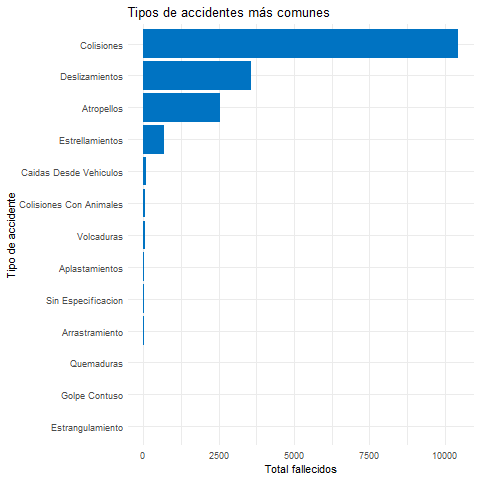

In [99]:
%%R

library(ggplot2)
df_clean %>%
  group_by(tipo_accidente) %>%
  summarise(total = sum(fallecidos, na.rm=TRUE)) %>%
  ggplot(aes(y = reorder(tipo_accidente, total), x = total)) +
  geom_bar(stat = "identity", fill = "#0073C2FF") +
  labs(title = "Tipos de accidentes más comunes", y = "Tipo de accidente", x = "Total fallecidos") +
  theme_minimal() +
  theme(axis.text.y = element_text(angle=0, hjust=1))

## **2️⃣ Que dias de la semana son mas propensos a accidentes graves?**

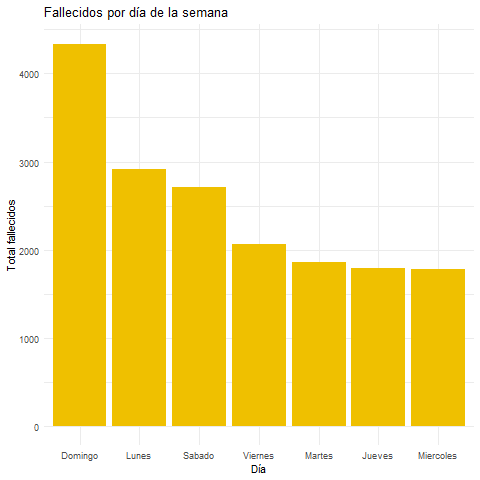

In [100]:
%%R
df_dia_semana %>%
  group_by(dia_semana) %>%
  summarise(total = sum(fallecidos, na.rm=TRUE)) %>%
  ggplot(aes(x = reorder(dia_semana, -total), y = total)) +
  geom_bar(stat = "identity", fill = "#EFC000FF") +
  labs(title = "Fallecidos por día de la semana", x = "Día", y = "Total fallecidos") +
  theme_minimal()

## **3️⃣ Accidentes a lo largo de los años**

In addition: Warning message:
Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
i Please use `linewidth` instead.
This warning is displayed once every 8 hours.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 


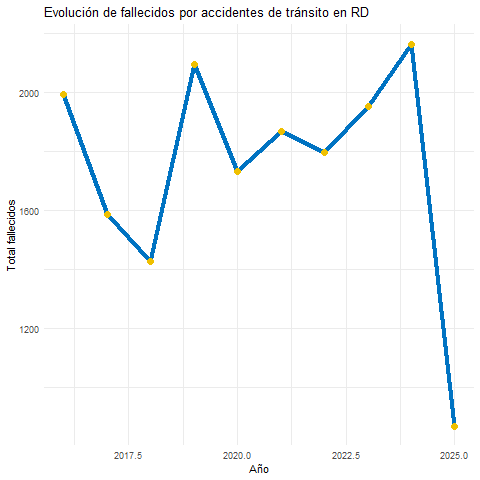

In [105]:
%%R
library(ggplot2)
df_provincias %>%
  group_by(anio) %>%
  summarise(Total = sum(fallecidos, na.rm=TRUE)) %>%
  ggplot(aes(x = anio, y = Total)) +
  geom_line(color = "#0073C2FF", size = 1.5) +
  geom_point(color = "#EFC000FF", size = 3) +
  labs(title = "Evolución de fallecidos por accidentes de tránsito en RD",
       x = "Año", y = "Total fallecidos") +
  theme_minimal()

- El año 2025 aun no ha terminado o el dataset solo incluye datos parciales (por ejemplo, hasta mitad de año).
- Por eso, el total nacional de fallecidos en 2025 es mucho menor y la grafica cae drasticamente.

## **4️⃣ Que zonas tienen mayor concentracion de accidentes?**

**Voy a poner en practica lo aprendido en la semana 4 y voy a hacer un grafico de mapas para esta visualizacion**

- ## **Carga de librerias y datos**

In [101]:
%%R

library(sf) # Para manejar datos espaciales
library(leaflet) # Para graficar mapas
library(dplyr) # Para manipular datos
library(IRdisplay) # Para mostrar resultados en Jupyter

provincias_geo <- st_read("C:/Users/josecarlos/Downloads/geoBoundaries-DOM-ADM1-all/geoBoundaries-DOM-ADM1.geojson")

Reading layer `geoBoundaries-DOM-ADM1' from data source 
  `C:\Users\josecarlos\Downloads\geoBoundaries-DOM-ADM1-all\geoBoundaries-DOM-ADM1.geojson' 


  using driver `GeoJSON'
Simple feature collection with 32 features and 5 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -72.00984 ymin: 17.54556 xmax: -68.3286 ymax: 19.93769
Geodetic CRS:  WGS 84


<hr style="
    border: none;
    border-top: 15px solid #014775ff;
    border-radius: 8px;
    width: 80%;
    margin: 80px auto;
">

- ## **Creacion de nuevo dataframe para `agrupacion de fallecimientos por provincia`**

In [102]:
%%R

# Agrupar fallecidos por provincia
fallecidos_prov <- df_provincias %>%
  group_by(provincia) %>%
  summarise(total_fallecidos = sum(fallecidos, na.rm = TRUE))

names(provincias_geo)

[1] "shapeISO"   "shapeName"  "shapeID"    "shapeGroup" "shapeType" 
[6] "geometry"  


<hr style="
    border: none;
    border-top: 15px solid #014775ff;
    border-radius: 8px;
    width: 80%;
    margin: 80px auto;
">

- ## **Union de datos por nombre de provincia**

In [103]:
%%R

mapa_data <- provincias_geo %>%
  left_join(fallecidos_prov, by = c("shapeName" = "provincia"))

<hr style="
    border: none;
    border-top: 15px solid #014775ff;
    border-radius: 8px;
    width: 80%;
    margin: 80px auto;
">

- ##  **Creacion del mapa**

In [104]:
%%R

mapa <- leaflet(mapa_data) %>%
  addTiles() %>%
  addPolygons(
    fillColor = ~colorNumeric("Reds", total_fallecidos)(total_fallecidos),
    weight = 1,
    color = "white",
    fillOpacity = 0.7,
    highlight = highlightOptions(
      weight = 3,
      color = "#666",
      fillOpacity = 0.9,
      bringToFront = TRUE
    ),
    label = ~paste0(shapeName, ": ", total_fallecidos)
  ) %>%
  addLegend(pal = colorNumeric("Reds", mapa_data$total_fallecidos),
            values = mapa_data$total_fallecidos,
            title = "Fallecidos por provincia",
            position = "bottomright")
  
print(mapa)

<hr style="
    border: none;
    border-top: 15px solid #014775ff;
    border-radius: 8px;
    width: 80%;
    margin: 80px auto;
">

# **👁️👁️**

- Los invito a ejecutar el codigo y visualizar el mapa, ya que este sale en el navegador en html
- Sin embargo he tomado una captura para una visualizacion breve de este

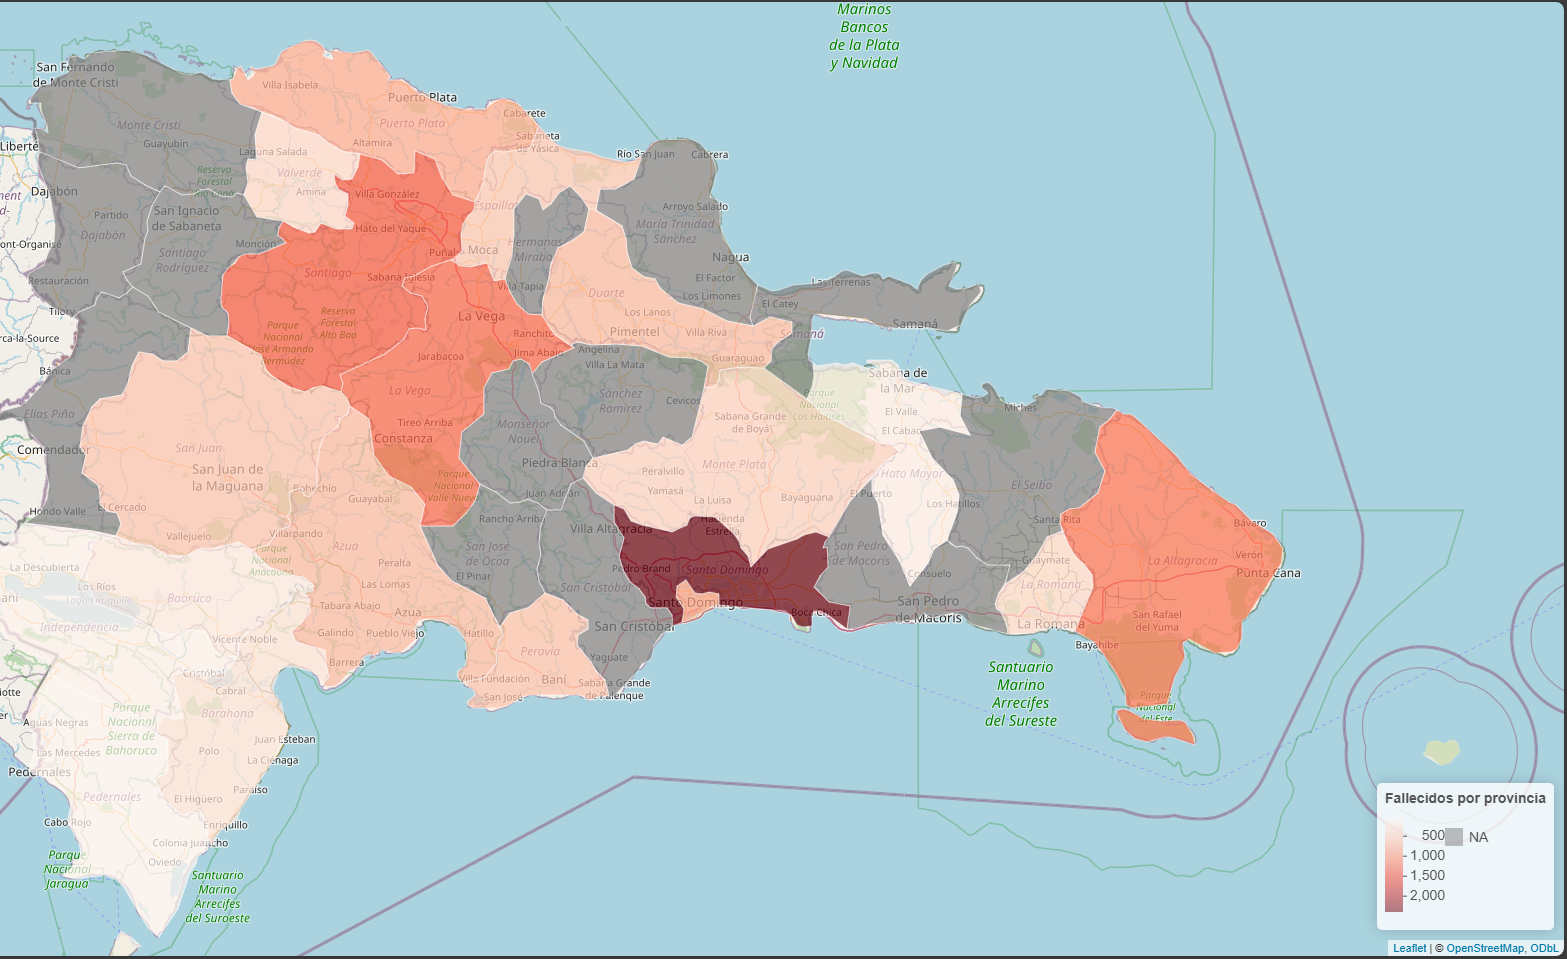

<hr style="
    border: none;
    border-top: 15px solid #014775ff;
    border-radius: 8px;
    width: 80%;
    margin: 80px auto;
">

## **Conclusiones Resumidas del Mapa**

- Mayor cantidad de fallecidos: Se concentra en Santo Domingo, Distrito Nacional, Santiago y La Altagracia (zonas urbanas y turisticas).
- Menor cantidad de fallecidos: En provincias rurales y fronterizas, como Pedernales, Elias Piña e Independencia.
- Relacion directa: A mayor poblacion y transito, mayor numero de accidentes fatales.


**Recomendacion: Priorizar campañas de prevencion en las provincias mas afectadas como las turisticas.**

## 🎉 **Resumen Final del Analisis en R**

<div style="
    font-family: 'Segoe UI', sans-serif;
    background: linear-gradient(135deg, #1735b8ff, #0a6296ff, #1385a1ff);
    color: white;
    padding: 28px 24px 18px 24px;
    border-radius: 18px;
    margin: 30px auto 30px auto;
    box-shadow: 0 8px 18px rgba(0,0,0,0.18);
    border-left: 8px solid #00cfff;
    max-width: 800px;
">

  <div style="display: flex; align-items: center; margin-bottom: 12px;">
    <span style="font-size: 2em; margin-right: 12px;">📊</span>
    <span style="font-size: 1.5em; font-weight: bold;">ANALISIS Y VISUALIZACION COMPLETADOS</span>
  </div>

  <ul style="font-size: 1.08em; line-height: 1.7; margin-bottom: 18px; padding-left: 1.2em;">
    <li><b>📈 ESTADISTICAS:</b> Resumenes claros y tablas descriptivas generadas</li>
    <li><b>🖼️ VISUALIZACIONES:</b> Graficos y mapas interactivos para interpretar los datos</li>
    <li><b>🔍 INSIGHTS:</b> Identificacion de tendencias, zonas criticas y dias de mayor riesgo</li>
    <li><b>✅ OBJETIVO LOGRADO:</b> Analisis integral y visual de los accidentes de transito en RD</li>
  </ul>

  <div style="background: rgba(255,255,255,0.18); padding: 12px 0; border-radius: 10px; margin-top: 10px;">
    <span style="font-weight: bold; font-size: 1.13em; color: #fff; letter-spacing: 1px;">
      🚦 ¡LISTO! RESULTADOS VISUALES Y CONCLUSIONES EXTRAIDAS CON R 🚦
    </span>
  </div>
</div>

<hr style="
    border: none;
    border-top: 15px solid #003366;
    border-radius: 8px;
    width: 80%;
    margin: 80px auto;
">

> # **Conclusiones del trabajo 🔚**

**Como siempre, encantado de tomar una materia con `Jose Aquino`. Aprecio y admiro mucho su metodologia, ya que siempre en cada asignacion se aprende `algo nuevo` y se mejora, que es la intencion que se tiene desde el principio. Lamentablemente este es el trabajo final, pero aun asi `me diverti al 100%` a lo largo de la asignatura.**

**Aqui basicamente lo que hice fue `analizar de pies a cabeza los datos` en `Python` y procesarlos para que en `R` se pueda estudiar y graficar de una manera eficiente. Destacar tambien que tuve la intencion de relaciones las `condiciones climaticas con los accidentes`, sin embargo la pagina `datos.gob.do` al parecer da problemas al descargar este dataset... pero bueno.**

**El uso de `R` y `Python` en un solo cuaderno me ha resultado bastante bien, aunque no se puede dejar de lado a `RStudio`... pero personalmente me ha gustado mas trabajar los dos lenguajes en un solo cuaderno a hacer 2 cuadernos `RMD` y `iPYNB`, y luego juntarlos, pero bueno cada quien tiene sus mañas.**

**Esperando volver a encontrarme tanto con el profesor como con retos como este, le deseo mucha suerte y gracias por querer que `seamos mejores`.**

> - **🔗Link del archivo .geojson🔗**: **https://www.geoboundaries.org/countryDownloads.html**

> - **🔗Link para descargar y ejecutar el codigo🔗: https://itlaedudo-my.sharepoint.com/:u:/g/personal/20240371_itla_edu_do/Edr7ZnntE0pFjc8ApnUnIRgBPLyAAkUgMO9Ez-cW3eUSuw?e=1zSGon**

<hr style="
    border: none;
    border-top: 15px solid #003366;
    border-radius: 8px;
    width: 80%;
    margin: 80px auto;
">

<div style="display: flex; justify-content: center; align-items: center; height: 300px;">
    <div style="background: linear-gradient(135deg, #28a745, #218838); color: white; width: 600px; height: 300px; border-radius: 30px; box-shadow: 0 8px 16px rgba(0, 0, 0, 0.3); font-size: 64px; font-weight: bold; text-align: center; display: flex; justify-content: center; align-items: center; border: 4px solid #1e7e34; position: relative;">
        <span style="text-shadow: 2px 2px 8px rgba(0, 0, 0, 0.5);">FIN</span>
        <p style="position: absolute; bottom: 15px; font-size: 14px; color: rgba(255, 255, 255, 0.7); font-style: italic;">Jose Carlos Fernandez</p>
    </div>
</div>